In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

from transformations import normalizer
from transformations import time_transform
from transformations import transform_to_standard_template
from transformations import test_train_split

In [2]:
df_pump = pd.read_parquet("pump_sensor_data_clean.pqt")

FileNotFoundError: [Errno 2] No such file or directory: 'pump_sensor_data_clean.pqt'

In [44]:
metric_columns=['metric1','metric2','metric3','metric4','metric5','metric6']

In [45]:
df_pump = normalizer(df_pump,metric_columns)
df_pump = time_transform(df_pump)

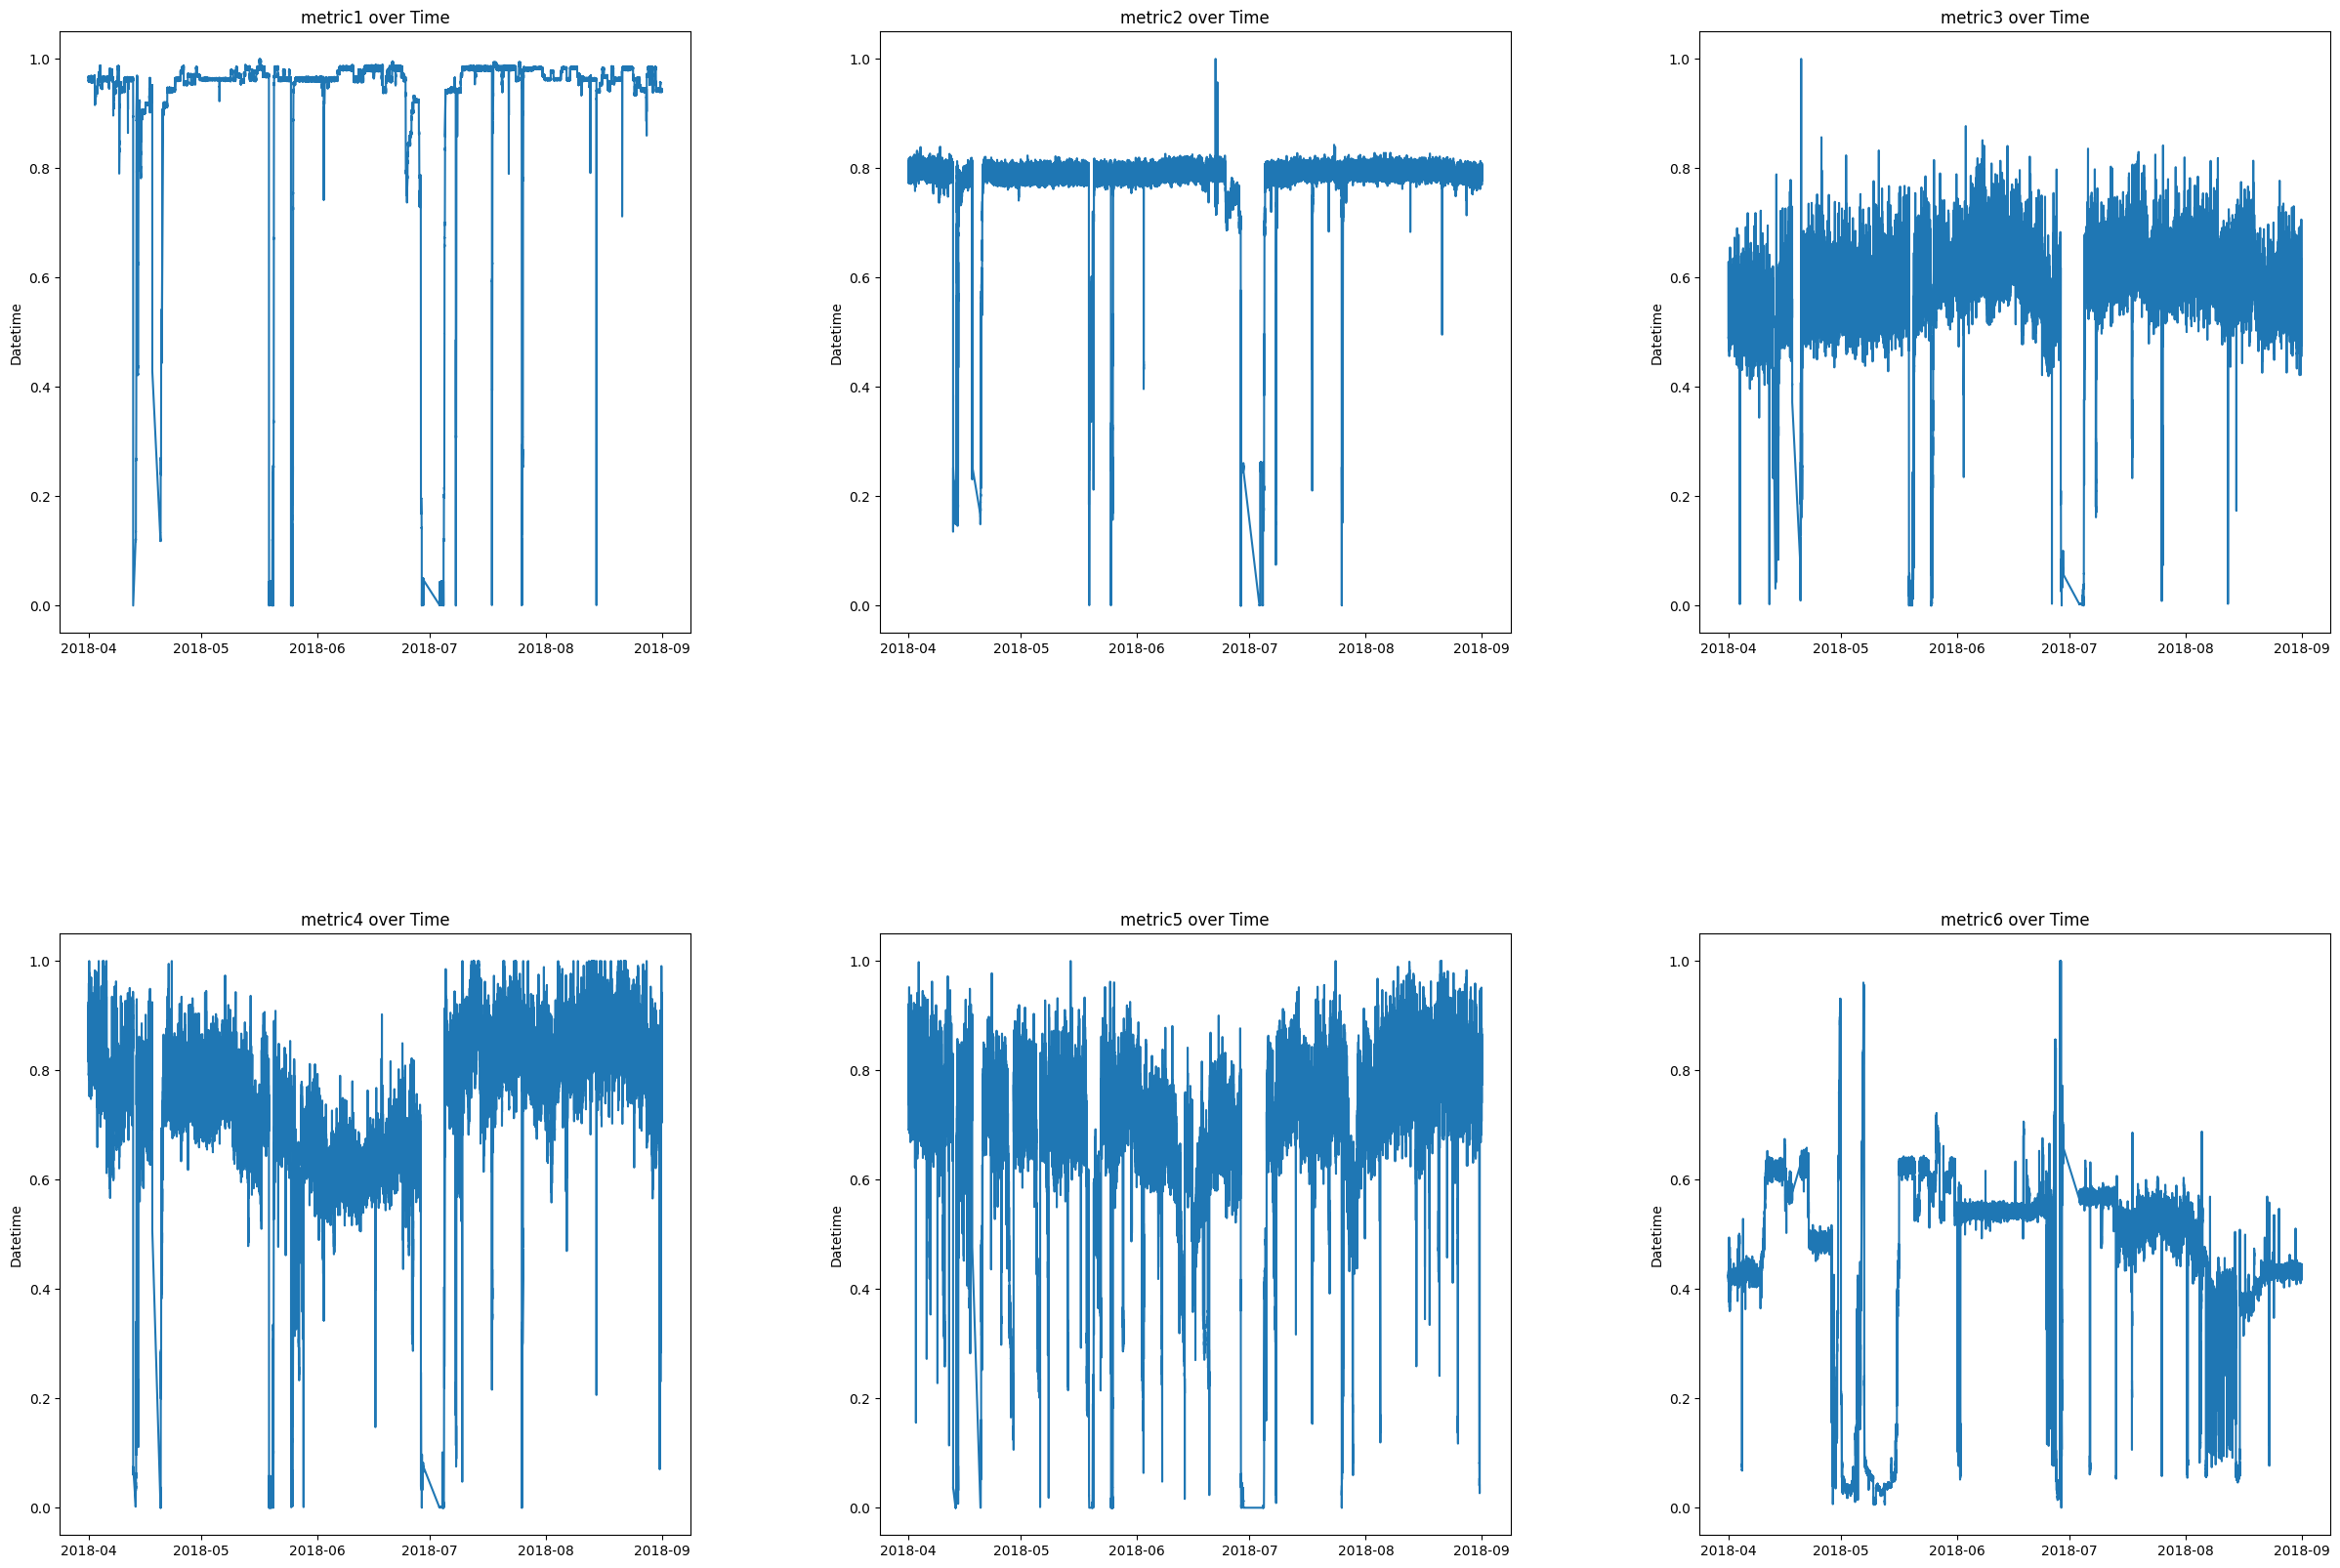

In [46]:
fig1 = plt.figure(figsize=(30, 20))
grid = fig1.add_gridspec(2, 3, hspace=0.5, wspace=0.3)

for i, col in enumerate(metric_columns):
    ax = fig1.add_subplot(grid[i // 3, i % 3])
    ax.plot(df_pump["timestamp"], df_pump[col])
    ax.set_ylabel("Datetime")
    ax.set_title(f"{col} over Time")

In [53]:
split_time = '2018-08-01'

In [54]:
X_train, X_test, y_train, y_test = test_train_split(df_pump, split_time)

In [57]:
print(f"X_train: {len(X_train)}")
print(f"X_test: {len(X_test)}")
print(f"Train test split: {1-len(X_test)/len(X_train)}")

X_train: 165470
X_test: 44637
Train test split: 0.7302411313228985


In [ ]:
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(units=50, return_sequences=False, input_shape=input_shape))
    model.add(Dense(units=1))  # Predicting one value (e.g., metric1)
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model